# JP Morgan Quantitative Research  - Task 1 (investigate and Analyze the Natural gas)

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from prophet import Prophet 

In [3]:
stringList = ['ab','ab','abc']
queries = ['ab', 'abc', 'abcd']


In [8]:
df = pd.read_csv('Nat_Gas.csv')
df['Dates'] = pd.to_datetime(df['Dates'], format='mixed')
df = df.rename(columns={'Dates': 'ds', 'Prices': 'y'})

In [9]:
df.head()

,ds,y
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


In [10]:
model = Prophet()
model.fit(df)

19:19:13 - cmdstanpy - INFO - Chain [1] start processing
19:19:15 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
def estimate_price(input_date_str):
    # Convert string input to datetime
    input_date = pd.to_datetime(input_date_str)
    
    # Prediction DataFrame from start of historical data to one year beyond latest date
    last_date = df['ds'].max()
    future_dates = pd.date_range(start=df['ds'].min(), end=last_date + timedelta(days=365), freq='D')
    future = pd.DataFrame({'ds': future_dates})
    
    forecast = model.predict(future)
    
    # Find closest date in forecast to input_date
    forecast['date_diff'] = (forecast['ds'] - input_date).abs()
    closest_row = forecast.loc[forecast['date_diff'].idxmin()]
    
    return closest_row['yhat']

In [12]:
print(estimate_price('2025-10-01')) 
print(estimate_price('2022-05-15'))


12.153201677701349
14.688120524881368


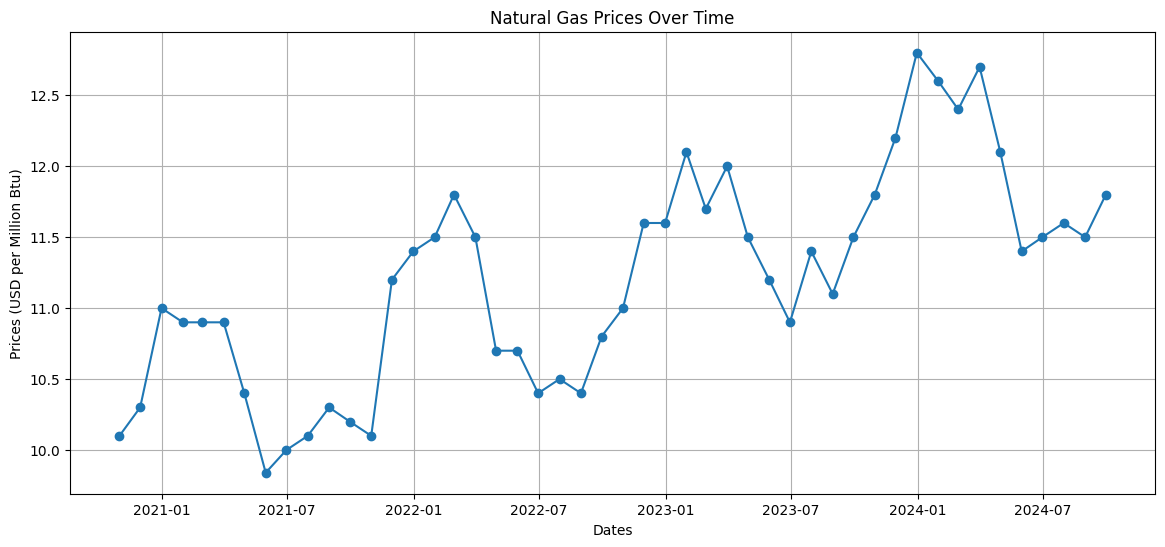

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(df['ds'], df['y'], marker='o', linestyle='-')
plt.title('Natural Gas Prices Over Time')
plt.xlabel('Dates')
plt.ylabel('Prices (USD per Million Btu)')
plt.grid(True)
plt.show()

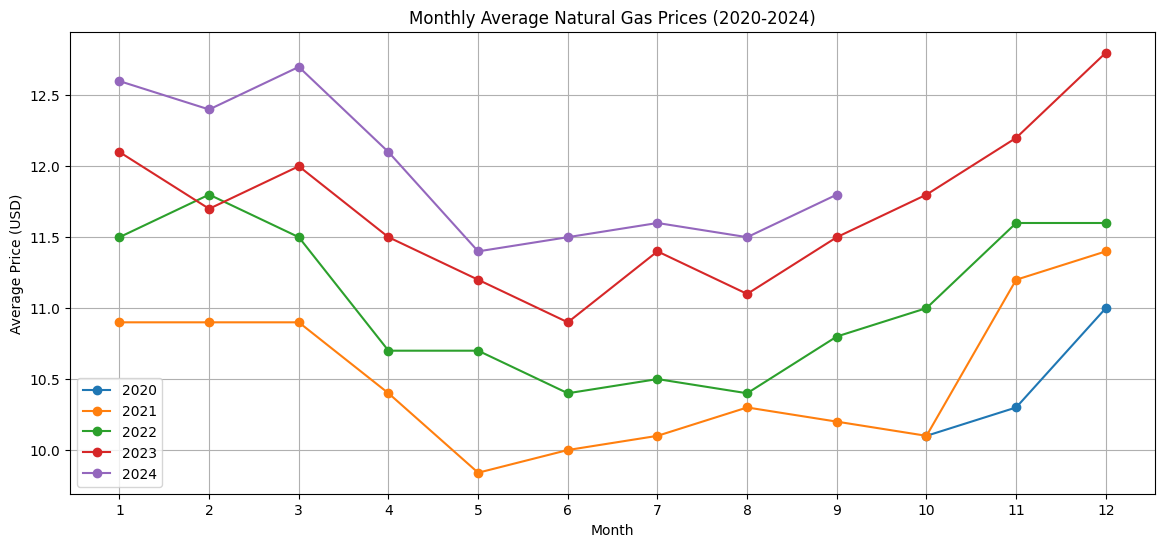

In [14]:
df['Month'] = df['ds'].dt.month
df['Year'] = df['ds'].dt.year

monthly_avg = df.groupby(['Year', 'Month'])['y'].mean().reset_index()

plt.figure(figsize=(14, 6))
for year in monthly_avg['Year'].unique():
    subset = monthly_avg[monthly_avg['Year'] == year]
    plt.plot(
        subset['Month'], 
        subset['y'], 
        marker='o', 
        label=str(year)
    )
plt.title('Monthly Average Natural Gas Prices (2020-2024)')
plt.xlabel('Month')
plt.ylabel('Average Price (USD)')
plt.legend()
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

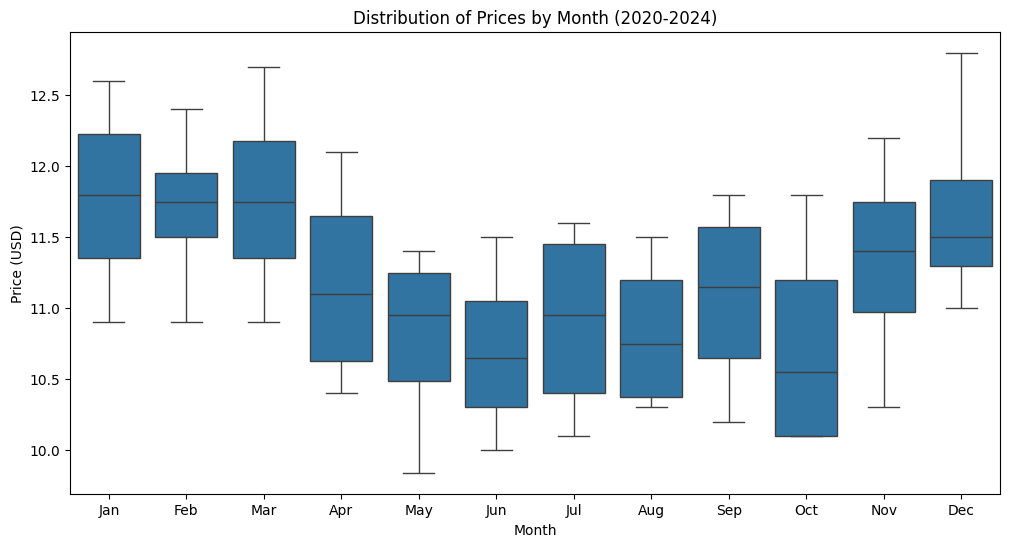

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='y', data=df)
plt.title('Distribution of Prices by Month (2020-2024)')
plt.xlabel('Month')
plt.ylabel('Price (USD)')
plt.xticks(ticks=range(0, 12), labels=[
    'Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'
])
plt.show()